# Document Loading

In [1]:
import hashlib # Used for creating chunk id
import numpy as np # Used for images .
import pymupdf # For PDF loading
from pathlib import Path # For Loading the directory or PDF path .
from typing import List,Dict
import traceback # Used for error handling .

In [2]:
# The following function is used to check if the image has detailing since if there is no much variance(Basically flat image) it removes it .
# threshold -> minimum variance value .
def is_low_variance(pix, threshold: int = 5) -> bool:

    try:
        if pix is None or pix.samples is None: # Checking if image is empty .
            return True

        samples = np.frombuffer(pix.samples, dtype=np.uint8) # Storing pixels (raw bytes) into numpy array .

        if len(samples)==0: # Checking if image array is empty .
             return True

        if pix.n >= 3:
            samples = samples.reshape(-1, pix.n)[:, :3].mean(axis=1) # Converting to grayscale

        return samples.std() < threshold # Returns True if standard variance is less than threshold .
    except Exception as e:
        print(f"Error in is_low_variance : {e}")
        return True

In [3]:
# The following function checks if image is mostly white .
# threshold -> 245 -> white
# ratio -> The threshold color present in the whole picture .
def is_mostly_white(pix, threshold=245, ratio=0.98) -> bool:

    try:
        if pix is None or pix.samples is None: # Checking if image is empty .
            return True

        samples = np.frombuffer(pix.samples, dtype=np.uint8) # Storing pixels (raw bytes) into numpy array .

        if len(samples)==0: # Checking if image array is empty .
             return True

        if pix.n >= 3:
            samples = samples.reshape(-1, pix.n)[:, :3].mean(axis=1)
        white_pixels = np.sum(samples > threshold) # Number of nearby white color variants in image .

        return (white_pixels / len(samples)) > ratio # Returns false if most of the pixels are white (Less than threshold) .
    except Exception as e:
        print(f"Error in is_mostly_white : {e}")
        return True

In [4]:
# Function to load all the PDF's from Directory .
def loading_pdf(dir_path:str='../data/pdf')->List[Dict]: # Return type .

    dir_path=Path(dir_path) # Loading directory Path

    if not dir_path.is_dir(): # Checking if the directory is valid .
        raise NotADirectoryError(f"{dir_path} is a invalid directory .")

    print(f"The directory path is : {dir_path} .")
    pdf_files=list(dir_path.rglob("*.pdf")) # Storing all the PDF's path into list .
    print(f"Number of PDF's in directory is {len(pdf_files)}")

    if len(pdf_files)==0: # Checking if any PDFs exists in the directory .
        print('No documents in the dir_path')
        return []

    # All these variables used for stats check at the end .
    all_pdf_size=0.0
    all_pages=[]
    failed_pdf=[]

    print("="*20,"PDF LOAD SUMMARY","="*20)
    print("-"*45)

    for serial,pdf_path in enumerate(pdf_files,start=1): # Iterating through all the PDFs in directory .
        print(f"{serial} ---> Loading {pdf_path.name} ")
        pdf_size_bytes=pdf_path.stat().st_size
        pdf_size_mb=pdf_size_bytes/(1024**2) # Calculating size of the PDF .
        print(f"File size : {pdf_size_mb:.3f} MB")

        pdf=None # For cleanup
        try:
            image_dir= Path('../data/images_pymupdf') / pdf_path.stem # Directory for storing images in the PDF .
            image_dir.mkdir(parents=True,exist_ok=True)

            pdf=pymupdf.open(filename=pdf_path,filetype="pdf") # Loading PDF .

            for page_num,page in enumerate(pdf,start=1):
                text_blocks=[] # Used for storing details about block of a page .
                page_images=[] # Used for storing images of current page .
                seen_xrefs=set()

                images=page.get_images(full=True) # Extracting images .

                for img_index,img in enumerate(images): # Extracting images .
                    pix=None # For cleanup

                    try:
                        if img[1]!=0: # Skip soft mask . soft mask -> Transparency layer
                            continue

                        xref=img[0]

                        if xref in seen_xrefs: # Checking if the same images are being stored
                            continue

                        seen_xrefs.add(xref)
                        rects=page.get_image_rects(xref) # Used for getting image edges .

                        if not rects: # Checking if coordinates or image is empty .
                            continue

                        pix=pymupdf.Pixmap(pdf,xref) # xref is used to find position if image in PDF .

                        if pix.width<50 or pix.height<50: # Removing very tiny images .
                            pix=None
                            continue

                        if pix.alpha and pix.samples is not None: # Removing fully transparent images .
                            if max(pix.samples)==0 and len(pix.samples)>0:
                                continue

                        if pix.n>4: # If image is CMY color format converting it into RGB .
                            pix=pymupdf.Pixmap(pymupdf.csRGB,pix)

                        if is_mostly_white(pix): # Checking if the image is mostly white .
                            pix=None
                            continue

                        if is_low_variance(pix): # Checking if its a flat image .
                            pix=None
                            continue

                        img_path=image_dir/f"page_{page_num}_img_{img_index}.png" # Location for storing images in local disk .
                        pix.save(img_path) # Saving images in local disk .
                        pix=None

                        rect=rects[0] # Changed the method since we needed only approx coordinates and not all approx coordinates to be merged , using a FOR loop made multiple copy of image .
                        page_images.append({
                            "image_id":f"{pdf_path.stem}_p{page_num}_i{img_index}",
                            "path":str(img_path),
                            "page":page_num,
                            "bbox":[rect.x0,rect.y0,rect.x1,rect.y1]
                        }) # For metadata .

                    except Exception as img_error:
                        print(f"Error processing image {img_index}")

                    finally:
                        if pix is not None:
                            pix=None

                # Following loop is to extract texts from a page .
                blocks=sorted(page.get_text("blocks"),key=lambda b:(b[1],b[0]))
                for block_id,b in enumerate(blocks):
                    x0,y0,x1,y1,text=b[:5] # Coordinates and text of text block .
                    text=text.strip()
                    if len(text) < 20: # If texts are smaller it is removed since smaller texts can not be very useful .
                        continue

                    block_bbox=[x0,y0,x1,y1] # Coordinates of the textblocks . Used while checking relevance of image and text .

                    text_blocks.append({
                        "block_id":block_id,
                        "text":text,
                        "bbox":block_bbox,
                        "page":page_num,
                    }) # Used while appending metadata .

                all_pages.append({
                    "source":pdf_path.name,
                    "page":page_num,
                    "text_blocks":text_blocks,
                    "images":page_images
                })
            all_pdf_size+=pdf_size_mb
            pdf.close()
            print("-"*45)
        except Exception as e:
            print(f" Error loading {pdf_path.name} . Error {e}") # Exception handling .
            failed_pdf.append(pdf_path.name) # Storing the PDF failed to load .
            traceback.print_exc() # Used to trace failures similar to python interpreter stack trace .
        finally:
            if pdf is None: # Closing pdf .
                pdf.close()

    # Some stats of Loading all the PDF in a directory .
    print(f"Total size of all the PDF's are : {all_pdf_size:.3f} MB")
    print(f"Total Number of pages extracted : {len(all_pages)} ")
    print("-"*45)

    # Printing all the PDF which where not able to load .
    if failed_pdf:
        print(f"Failed PDF : {failed_pdf}")

    return all_pages # Returning the loaded pages .

In [5]:
pages=loading_pdf(dir_path="../data/pdf")

The directory path is : ..\data\pdf .
Number of PDF's in directory is 3
==================== PDF LOAD SUMMARY ====================
---------------------------------------------
1 ---> Loading highlights_of_hubbles_exploration_of_the_universe.pdf 
File size : 9.853 MB
---------------------------------------------
2 ---> Loading mars-science-laboratory.pdf 
File size : 1.442 MB
---------------------------------------------
3 ---> Loading Voyager Grand Tour PDF.pdf 
File size : 0.666 MB
---------------------------------------------
Total size of all the PDF's are : 11.961 MB
Total Number of pages extracted : 30 
---------------------------------------------


# Chunking

In [6]:
from langchain_core.documents import Document # Datatype of a block or a chunk .
from typing import List # Used to store list of Documents or to specify return type .
from typing import Tuple

In [7]:
# The following function is to calculate distance between two blocks and a threshold is set such that if two blocks are far those both blocks are separated with different chunks .
def vertical_gap(block1,block2)->float:
    return block2["bbox"][1]-block1["bbox"][3] # Distance between bottom of block 1 and top of block 2.

In [8]:
# The following function is used for getting outermost edge of all the chunks combined .
def merge_bbox(blocks):
    if not blocks:
        return None

    return(
        min(b["bbox"][0] for b in blocks), # x0 left
        min(b["bbox"][1] for b in blocks), # y0 top
        max(b["bbox"][2] for b in blocks), # x1 right
        max(b["bbox"][3] for b in blocks)  # y1 bottom
    )

In [9]:
# The following function creates a constant chunk id for same text .
def stable_chunk_id(source: str, page_num:int,text:str)->str:
    h=hashlib.md5(text.encode("utf-8")).hexdigest()[:8]
    return f"{source}_p{page_num}_c{h}"

In [10]:
# The following function is used to check if a block is relevant to another block using coordinates .
def bbox_overlap(a,b)->bool:
    return not(
        a[2] < b[0] or # right edge of a and left edge of b (here we are considering a is at left and b is right side of a .)
        a[0] > b[2] or # left edge of a and right edge of b (here we are considering b is at left and a is right side of b .)
        a[3] < b[1] or # bottom edge of a and top edge of b (here we are considering a is at top and b is below of a .)
        a[1] > b[3]    # top edge of a and bottom edge of b (here we are considering b is at top and a is below of b .)
    )

In [11]:
# The following function helps to identify if the text block near the image is caption of the image based on the coordinates and length of the text .
def is_caption_block(text_block:Dict,image:Dict,max_words:int=60,max_vertical_dist:int=80)->bool:

    text=text_block.get("text","") # Text

    if not text or len(text.split()) > max_words: # Checking if the text is large .
        return False

    tb_bbox=text_block.get("bbox") # Fetching text block bbox .
    im_bbox=image.get("bbox") # Fetching image block bbox .

    if not tb_bbox or not im_bbox: # Checking if image bbox is empty .
        return False

    tb_x0,tb_y0,tb_x1,tb_y1=tb_bbox # Coordinates of text block .
    im_x0,im_y0,im_x1,im_y1=im_bbox # Coordinates of image .

    horizontal_overlap=not(tb_x1 < im_x0 or tb_x0 > im_x1) # Check for horizontal overlap .

    vertical_distance=min( # Vertical distance between text block and image .
        abs(tb_y0 - im_y1),
        abs(im_y0 - tb_y1)
    )
    return horizontal_overlap and vertical_distance <= max_vertical_dist # Returns false if any condition fails .

In [12]:
# The following function get images that overlap with a chunk's bbox .
def get_overlapping_images(chunk_bbox:Tuple,page_images:List[Dict],vertical_tolerance:int =200,horizontal_tolerance:int=50) ->List[str]:
    if not chunk_bbox or not page_images:
        return []

    overlapping_ids=[]

    chunk_x0, chunk_y0, chunk_x1, chunk_y1 = chunk_bbox

    for img in page_images:
        img_bbox=img.get("bbox")
        if not img_bbox :
            continue

        img_x0, img_y0, img_x1, img_y1 = img_bbox

        # Check for horizontal overlap or proximity
        horizontal_overlap = not (
            chunk_x1 + horizontal_tolerance < img_x0 or
            chunk_x0 > img_x1 + horizontal_tolerance
        )

         # Calculate vertical distance between chunk and image
        vertical_distance = min(
            abs(chunk_y0 - img_y1),  # Distance from chunk top to image bottom
            abs(img_y0 - chunk_y1),  # Distance from image top to chunk bottom
            abs(chunk_y0 - img_y0),  # Distance between tops
            abs(chunk_y1 - img_y1)   # Distance between bottoms
        )

        # Method 1: Check if horizontally aligned and vertically close
        if horizontal_overlap and vertical_distance <= vertical_tolerance:
            overlapping_ids.append(img["image_id"])
        # Method 2: Or if they actually overlap perfectly
        elif bbox_overlap(chunk_bbox, img_bbox):
            overlapping_ids.append(img["image_id"])

    return overlapping_ids

In [13]:
# Build image objects , mainly used for embedding using openclip and also can be used parallely with text block in graph db .
def build_image_objects(pages:List[Dict])->List[Dict]:

    image_objects=[]

    # Getting text block and images from the page .(For reference this are the pages already loaded from pdf_loading .)
    for page in pages:
        source=page.get("source","unknown")
        page_num=page.get("page",0)
        text_blocks=page.get("text_blocks",[])
        images=page.get("images",[])

        # For every text block in page checking if the image is relevant or caption to it .
        for img in images:
            caption_blocks=[
                tb["text"] for tb in text_blocks
                if tb.get("text") and is_caption_block(tb,img)
            ]

            caption_text=" ".join(caption_blocks).strip() or None # Caption gathered from text blocks .

            # Appending image objects .
            image_objects.append({
                "image_id":img.get("image_id","unknown"),
                "type":"image",
                "modality":"vision",
                "source":source,
                "page_num":page_num,
                "bbox":img.get("bbox"),
                "path":img.get("path"),
                "caption_text":caption_text
            })

    return image_objects # List of image objects with relevant metadata .

In [14]:
# The following function is used create a chunk by adding
def build_chunk(source:str,page_num:int,blocks:List,page_images:List[Dict],related_image_ids:List[str] | None=None)->Document:

    if not blocks:
        return None

    chunk_text="\n".join(b.get("text","") for b in blocks) # Combing all the texts from the blocks .

    if not chunk_text.strip(): # Checking if the text blocks are empty .
        return None

    chunk_bbox=merge_bbox(blocks) # Used to get overall chunk coordinates .

    if related_image_ids is None: # If no related images then fetch related images based on bbox overlap .
        related_image_ids=get_overlapping_images(chunk_bbox,page_images)

    return Document(
        page_content=chunk_text,
        metadata={
            "source":source,
            "page_num":page_num,
            "bbox":chunk_bbox,
            "chunk_id":stable_chunk_id(source,page_num,chunk_text),
            "related_image_ids":related_image_ids or []
        }
    ) # Adding metadata .

In [15]:
# The following function is main chunking strategy ,it uses bbox , max characters to chunk different blocks together .
# max_chars -> maximum characters in a single chunk .
# (I guess we can replace with token based chunking using tiktoken need to check on that .)

# max_vertical_gap -> maximum vertical height between two blocks .
# Calculated using bbox .

# overlap_chars -> number of characters to overlap between consecutive chunks
# (0 means no overlap – same behavior as original bbox_chunker)

def bbox_chunker(
    pages: List[Dict],
    max_chars: int = 1000,
    max_vertical_gap: int = 40,
    overlap_chars: int = 0
) -> List[Document]:

    all_chunks = []  # Used to store chunks .

    # Extracting data from a dictionary .
    for page in pages:
        source = page.get("source", "")
        page_num = page.get("page", 0)
        blocks = page.get("text_blocks", [])
        page_images = page.get("images", [])  # Getting images in a page .

        if not blocks:
            continue

        i = 0
        while i < len(blocks):

            current_blocks = []  # Used to store blocks to store in a chunk .
            current_len = 0      # Calculating maximum characters in chunk .
            start_i = i          # Used to prevent infinite loop during overlap

            # Building a chunk until max_chars or vertical gap threshold
            while i < len(blocks):
                block = blocks[i]
                text = block.get("text", "")

                if not text:
                    i += 1
                    continue

                block_len = len(text)  # Calculating characters in a single block .

                if current_blocks:
                    gap = vertical_gap(current_blocks[-1], block)
                else:
                    gap = 0  # Basically first block of a page .

                # Checking conditions for creating a chunk .
                # (Basically threshold that chunk should have certain number of characters and text block distances .)
                if current_blocks and (
                    current_len + block_len > max_chars
                    or gap > max_vertical_gap
                ):
                    break

                current_blocks.append(block)
                current_len += block_len
                i += 1

            # Creating chunk from collected blocks .
            if current_blocks:
                chunk = build_chunk(source, page_num, current_blocks, page_images)
                if chunk:
                    all_chunks.append(chunk)  # Creating a chunk and appending it .

            # Step back to create overlap for next chunk .
            if overlap_chars > 0 and i < len(blocks):
                overlap_len = 0
                step_back = 0

                # Counting how many blocks to include in overlap .
                for j in range(len(current_blocks) - 1, -1, -1):
                    block_text = current_blocks[j].get("text", "")
                    if overlap_len + len(block_text) <= overlap_chars:
                        overlap_len += len(block_text)
                        step_back += 1
                    else:
                        break

                # Move index back safely (avoid infinite loop) .
                i = max(start_i + 1, i - step_back)

    print(
        f"{len(all_chunks)} chunks were created from {len(pages)} pages "
        f"(max_chars={max_chars}, overlap_chars={overlap_chars})"
    )

    return all_chunks

In [16]:
image_objects=build_image_objects(pages)

In [17]:
chunks=bbox_chunker(pages)

97 chunks were created from 30 pages (max_chars=1000, overlap_chars=0)


# Embedding

In [18]:
import numpy as np # Used for storing embeddings .
import torch # For device selection , model execution and tensor operation .
from PIL import Image # Used for image creation and other image operation .
import open_clip # Image embedding model .
from typing import List, Dict # Used for type return .

In [19]:
# Used for loading embedding model and embedding images with their caption .
class ImageEmbeddingModel:
    def __init__(self,model_name:str="ViT-B-32",pretrained:str="laion2b_s34b_b79k"):

        self.device="cuda" if torch.cuda.is_available() else "cpu" # Used to check if the machine has GPU if not assign CPU as device for working .
        try:
            self.model,self.preprocess,_=open_clip.create_model_and_transforms(
                model_name=model_name,
                pretrained=pretrained
            ) # Getting essential function from model .
            self.tokenizer=open_clip.get_tokenizer(model_name)

        except Exception as e:
            raise RuntimeError(f"Failed to load OpenClip model : {e}")


        self.model=self.model.to(self.device) # Device selection for model operations .
        self.model.eval() # Loading model

        # Displaying device on which model will run .
        if self.device=="cuda":
            print(f"OpenClip running on {torch.cuda.get_device_name(0)} .")
        else:
            print("OpenClip running on CPU .")
        print(f"Embedding dimension of {model_name} is {open_clip.get_model_config(model_name).get('embed_dim')}")

    # Using no grad since by default torch assumes it is used for training model and do various backpropagation tasks which are not required here and only forward pass is required .
    @torch.no_grad()
    def embed_image(self,image_objects:List[Dict])->np.ndarray:
        if not image_objects:
            raise ValueError("No images in the image object .")

        image_objects_embeddings=[] # Used for storing image embeddings .

        for image_object in image_objects: # Iterating through image objects .
            image_path=image_object.get("path") # Fetching location of image.

            try:
                image=Image.open(image_path).convert("RGB") # Converting RGB if image is not already in RGB .
            except Exception as e:
                print(f"Failed to load {image_path} : {e}")
                continue

            image_tensor=self.preprocess(image).unsqueeze(0).to(self.device) # Converting into tensor since openclip cant embedd other inputs .

            emb_imag=self.model.encode_image(image_tensor) # Embedding images
            emb_imag=emb_imag/emb_imag.norm(dim=-1,keepdim=True) # Normalizing images

            emb_imag=emb_imag.cpu().numpy()[0] # Converting tensor output to numpy array . Using .cpu since numpy cannot access gpu memory ,it should be in ram memory then numpy can access memory and can convert it into numpy array .

            caption = image_object.get("caption_text") or ""
            caption = caption.strip() if isinstance(caption, str) else ""
            if caption: # If caption is available for the image then embedd it .

                tokens=self.tokenizer([caption]).to(self.device) # Used to convert into tensor .

                emb_text=self.model.encode_text(tokens) # Embedding text or tensor value .
                emb_text=emb_text/emb_text.norm(dim=-1,keepdim=True) # Normalizing values

                emb_text=emb_text.cpu().numpy()[0] # Converting tensor to numpy array .

                fused=0.7*emb_imag+0.3*emb_text # Fusing image and caption together .It does not change the meaning . Adding more weight to image compared to caption .

                norm= np.linalg.norm(fused)
                if norm > 0:
                    fused=fused / norm # Normalizing fused values .

                image_objects_embeddings.append(fused) # Appending embeddings .

            else:
                image_objects_embeddings.append(emb_imag) # If no captions only images are embedded and appended .

        if not image_objects_embeddings: # Checking if image embeddings is empty .
            raise ValueError("No valid images were processed. All images failed to load .")

        return np.vstack(image_objects_embeddings) # Returning all the embeddings .

    @torch.no_grad()
    def embed_query(self,query:str)->np.ndarray:
        if not isinstance(query,str): # Checking if query is valid .
            raise TypeError("Query must be a string .")

        if not query.strip():
            raise ValueError("Please give a valid prompt .")

        tokens=self.tokenizer([query]).to(self.device) # Used to convert into tensor .
        query_embedding=self.model.encode_text(tokens) # Embedding text or tensor value .
        query_embedding=query_embedding/query_embedding.norm(dim=-1,keepdim=True) # Normalizing values
        query_embedding=query_embedding.cpu().numpy()[0] # Converting tensor to numpy array .

        return query_embedding # Returning all the embeddings .

In [20]:
from sentence_transformers import SentenceTransformer # Used for loading model .
import numpy as np # Used to store embedding .
import torch # Used for device selection and model execution .
from typing import List # Used for return type .
from langchain_core.documents import Document # Used for storing documents .

In [21]:
# Used for loading model and embedding text .
class TextEmbeddingModel:

    def __init__(self,model_name:str= "BAAI/bge-base-en-v1.5"):
        self.device="cuda" if torch.cuda.is_available() else "cpu" # Device check .

        try:
            self.model=SentenceTransformer(model_name_or_path=model_name,device=self.device) # Loading model .
        except Exception as e:
            raise RuntimeError(f"Failed to load SentenceTransformer model: {e}")

        self.query_prefix="Represent this sentence for searching relevant passages: "

        if self.device=="cuda":
            print(f"BGE running on {torch.cuda.get_device_name(0)} .")
        else:
            print("BGE running on CPU .")
        print(f"Embedding dimension of {model_name} is {self.model.get_sentence_embedding_dimension()}")

    @torch.no_grad()
    def embed_documents(self,documents:List[Document])->np.ndarray:
        if not documents:
            raise ValueError("No documents to embed .")

        texts=[]
        for doc in documents: # Checking if data is available in documents .
            if hasattr(doc,"page_content") and doc.page_content:
                content=doc.page_content.strip()
                if content:
                    texts.append(content)

        if not texts:
            raise ValueError("No valid document content to embed .All documents are empty .")

        # Embedding texts .
        # sentences -> input /texts
        # batch_size -> Number of inputs embedding a single time .
        # convert_to_numpy -> Convert output to numpy array .
        # normalize_embeddings -> Normalizing all the out vectors .
        text_embeddings=self.model.encode(
            sentences=texts,
            batch_size=32,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False
        )

        return text_embeddings # Return embeddings .

    # The following function is used to create embedding for user input prompt .
    @torch.no_grad()
    def embed_query(self,query:str)->np.ndarray:
        if not isinstance(query, str): # Checking if query is valid .
            raise TypeError("Query must be a string.")

        if not query.strip(): # Checking if the prompt is not empty .
            raise ValueError("Given prompt is not valid .")

        query=self.query_prefix + query # Adding a prefix to prompt since BGE is instruction based embedding model .(Only for prompt not mandatory for documents)

        query_embedding=self.model.encode( # Embedding query .
            sentences=query,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False
        )

        return query_embedding # Returning embedded values .

In [22]:
image_model = ImageEmbeddingModel() # Loading model .

OpenClip running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Embedding dimension of ViT-B-32 is 512


In [23]:
text_model = TextEmbeddingModel() # Loading model .

BGE running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Embedding dimension of BAAI/bge-base-en-v1.5 is 768


In [24]:
image_embeddings=image_model.embed_image(image_objects=image_objects)

In [25]:
text_embeddings=text_model.embed_documents(chunks)

# VectorStore

In [26]:
import json # Used for receiving image object or document while creating a hash id .
from typing import List,Dict,Union,Optional # For datatype of a variable .
import chromadb # Used for creating a vectorDB .
import os # For getting directory path for storing vector database .
import hashlib # Used for creating hashid for documents
import numpy as np
from langchain_core.documents import Document

In [27]:
# The following function is used to create hashid using content of a document or image object .
def stable_hash(obj:dict|str)->str:
    if isinstance(obj,dict):
        obj=json.dumps(obj,sort_keys=True,ensure_ascii=False)
    elif not isinstance(obj,str):
        raise TypeError(f"stable_hash expects dict or str, got {type(obj)}")

    return hashlib.sha256(obj.encode("utf-8")).hexdigest()

In [28]:
# The following function is used to remove None type and replace it with empty string since chromadb cannot store type None .
def sanitize_metadata(metadata: dict) -> dict:
    if not isinstance(metadata,dict): # Type validation .
        raise TypeError(f"sanitize_metadata expects dict , got {type(metadata)}")

    clean = {}
    for k, v in metadata.items():
        if v is None:
            clean[k] = "" # None -> Empty string
        elif isinstance(v, (str, int, float, bool)):
            clean[k] = v # Keep it as it is .
        else:
            clean[k] = str(v) # Convert unknown type to string .
    return clean # Return sanitized metadata .


In [29]:
# Used for initializing vectorDB and also store data in collection .
class VectorStore:
    def __init__(self,collection_name:str,directory:str="../data/database"):
        if not collection_name or not isinstance(collection_name,str):
            raise ValueError("Collection name must be a non-empty string .")

        self.collection_name=collection_name # Collection name .
        self.persistent_directory=directory # Directory to store database .
        self.collection=None # Collection , used to store data .
        self.client=None # Used to connect database .
        self.initialize_store() # Initializing vectordb .

    def initialize_store(self):
            try:
                os.makedirs(name=self.persistent_directory,exist_ok=True) # Checking if directory exists ,if not creating one .
                self.client=chromadb.PersistentClient(path=self.persistent_directory)

                if self.collection_exists(self.collection_name): # Checking if the collection exists , if collection exists then loading it .
                    print(f"Loading collection {self.collection_name} from database .")
                    self.collection=self.client.get_collection(self.collection_name)

                else: # If collection does not exist then creating it .
                    print(f"New collection {self.collection_name} created in database .")
                    self.collection=self.client.create_collection(name=self.collection_name,metadata={"hnsw:space":"cosine"})

                print(f"Vector store initialized .") # Success message is vector store initialized .
                print(f"Existing documents in collection : {self.collection.count()}")

            except Exception as e: # Exception handling .
                raise RuntimeError(f"Could not initialize vector store : {e}") from e

    # The following function is used to add data and its embedding to a collection .
    def add_documents(self,documents:List[Union[Dict,Document]],embeddings:np.ndarray):
        if not self.collection: # Checking if collection is initialized .
            raise RuntimeError("Collection is not initialized .")

        if not documents:
            raise ValueError("Documents list is empty .")

        if len(documents)!=len(embeddings): # Checking if number of documents and embeddings are same .
            raise ValueError(f"Number of documents ({len(documents)}) does not match embeddings ({len(embeddings)}).") # If not raise an error

        ids,metadatas,texts=[],[],[] # Used to store main content and metadata .

        for doc in documents:
            if isinstance(doc,Document): # For text embeddings . Document type .
                content=doc.page_content.strip()
                if not content:
                    continue

                metadata=doc.metadata or {}
                metadata=sanitize_metadata(metadata)

                hash_input={ # Data used for creating hashid .
                    "content":content,
                    "source":metadata.get("source"),
                    "page":metadata.get("page_num","")
                }
                doc_id=stable_hash(hash_input)

                texts.append(content) # Appending data to store it in vectorDB
                metadatas.append(metadata)
                ids.append(doc_id)

            elif isinstance(doc,dict): # For image embeddings . Dict type .
                bbox = doc.get("bbox")
                image_metadata = {
                "image_path": doc.get("path", ""),
                "caption_text": doc.get("caption_text", ""),
                "bbox": json.dumps(bbox) if bbox is not None else "",
                }

                image_metadata = sanitize_metadata(image_metadata) # Removing None or unknown datatype .

                hash_input = { # Used for hashid .
                "image_path": image_metadata["image_path"],
                "bbox": image_metadata["bbox"],
                "caption": image_metadata["caption_text"],
                }

                doc_id=stable_hash(hash_input)

                texts.append(doc.get("caption_text","")) # Appending data to store it in vectorDB
                metadatas.append(image_metadata)
                ids.append(doc_id)

            else:
                raise TypeError(f"Unsupported document type :{type(doc)}") # If the input neither Document nor Dict .

        if not ids:
            print("No valid documents to process .")

        existing_ids=set( # Used to check if the document is previously added .
            self.collection.get(include=[])["ids"]
        )

        seen=set()
        new_indices=[]

        for i, doc_id in enumerate(ids): # Check for redundant documents .
            if doc_id in existing_ids:
                continue
            if doc_id in seen:
                continue
            seen.add(doc_id)
            new_indices.append(i)

        if not new_indices: # Checking if there are new documents to add to collection .
            print("No new documents to add")
            return

        self.collection.add( # Adding new documents to collection
            ids=[ids[i] for i in new_indices],
            documents=[texts[i] for i in new_indices],
            metadatas=[metadatas[i] for i in new_indices],
            embeddings=[embeddings[i].tolist() for i in new_indices]
        )
        print(f"Added {len(new_indices)} new documents to collection .")

    # The following function is used to check if the collection exists .
    def collection_exists(self,collection_name:str)->bool:
        collection_in_db=self.client.list_collections()
        return any(col.name==collection_name for col in collection_in_db )

    # The following function is used get queries and get relevant documents
    def query(self,query_embedding:np.ndarray,k:int=5,where:Optional[Dict]=None):

        if not self.collection: # Checking is collection is initialized .
            raise RuntimeError("Collection is not initialized .")

        if query_embedding.ndim!=1: # Checking if query is 1 dimensional .
            raise ValueError("Query embedding must be a 1D vector .")

        if not isinstance(k,int) or k <= 0:
            raise ValueError(f"k must be a positive integer ,got {k} .")

        results=self.collection.query( # Storing results .
            query_embeddings=[query_embedding.tolist()],
            n_results=k, # Getting top results .
            where=where, # Acts as a filter .
            include=["documents","metadatas","distances"] # Including the following data .
        )
        return results

    # The following function is used get stats about the collection .
    def get_collection_stats(self)->Dict:
        if not self.collection:
            raise RuntimeError("Collection is not initialized .")

        return {
            "name":self.collection_name,
            "count":self.collection.count(),
            "directory":self.persistent_directory
        }

    # The following collection is used to delete current collection .
    def delete_collection(self)->None:
        if not self.collection:
            raise RuntimeError("Collection is not initialized .")

        self.client.delete_collection(name=self.collection_name)
        self.collection=None
        print(f"Collection {self.collection_name} deleted .")

In [30]:
image_vector_store=VectorStore(collection_name="OpenClip_embeddings")

New collection OpenClip_embeddings created in database .
Vector store initialized .
Existing documents in collection : 0


In [31]:
text_vector_store=VectorStore(collection_name="BGE_embeddings")

New collection BGE_embeddings created in database .
Vector store initialized .
Existing documents in collection : 0


In [32]:
text_vector_store.add_documents(documents=chunks,embeddings=text_embeddings)

Added 97 new documents to collection .


In [33]:
image_vector_store.add_documents(documents=image_objects,embeddings=image_embeddings)

Added 99 new documents to collection .


# Retrieval

In [34]:
from PIL import Image
import os
from typing import List,Dict,Optional

# Context formatter

In [35]:
# Used to format retrieved docs from retrieval output .
class ContextFormatter:

    def __init__(self,max_text_chunks:int=3,max_images:int=1,text_distance_threshold:float=0.65,image_distance_threshold:float=0.95):
        if not isinstance(max_text_chunks, int) or max_text_chunks <= 0: # Threshold value validation .
            raise ValueError(f"max_text_chunks must be a positive integer, got {max_text_chunks}.")

        if not isinstance(max_images, int) or max_images <= 0:
            raise ValueError(f"max_images must be a positive integer, got {max_images}.")

        if not isinstance(text_distance_threshold, (int, float)) or text_distance_threshold < 0:
            raise ValueError(f"text_distance_threshold must be a non-negative number, got {text_distance_threshold}.")

        if not isinstance(image_distance_threshold, (int, float)) or image_distance_threshold < 0:
            raise ValueError(f"image_distance_threshold must be a non-negative number, got {image_distance_threshold}.")

        self.max_text_chunks=max_text_chunks # Limiting number of chunks .
        self.max_images=max_images # Limiting number of max images .
        self.text_distance_threshold=float(text_distance_threshold) # Threshold for filtering chunks .
        self.image_distance_threshold=float(image_distance_threshold) # Threshold for filtering images .

    # Removing unwanted details from results .
    def _flatten_results(self,results:Dict)->List[Dict]:

        if not results or not isinstance(results,dict): # Checking if data is empty .
            return []

        documents = results.get("documents", [[]])
        metadatas = results.get("metadatas", [[]])
        distances = results.get("distances", [[]])

        # Check if we have valid nested lists .
        if not documents or not documents[0]:
            return []

        docs = documents[0] if len(documents) > 0 else []
        metas = metadatas[0] if len(metadatas) > 0 else []
        dists = distances[0] if len(distances) > 0 else []

        # Ensure all lists have the same length .
        min_length = min(len(docs), len(metas), len(dists))
        if min_length == 0:
            return []

        flattened=[]
        for i in range(min_length):
            flattened.append({ # Appending required data .
                "text":docs[i],
                "metadata":metas[i],
                "distance":float(dists[i])
            })

        return flattened # Returning flattened data .

    # The following function is used to load image from path .
    def _load_image(self,image_path:str) -> Optional[Image.Image]:

        if not image_path or not isinstance(image_path, str): # Checking is image path is valid .
            return None

        if not os.path.exists(image_path):
            print(f"Warning: Image path does not exist: {image_path}")
            return None

        try:
            return Image.open(image_path).convert("RGB") # Returning loaded image .
        except Exception as e:
            print(f"Failed to load image {image_path}: {e}")
            return None

    # The following function is filter text chunks based on distance .
    def _select_text_chunks(self,text_results:Dict)->List[Dict]:
        items=self._flatten_results(text_results) # Removing unwanted data from results .

        if not items: # Checking if items is empty .
            return []

        filtered=[
            i for i in items
            if i["distance"] <= self.text_distance_threshold # Filtering based on distance .
        ]

        if not filtered: # If there is no chunks (All the chunks distance greater than threshold) just return retrieved chunks .

            items.sort(key=lambda x:x["distance"])
            return items[: self.max_text_chunks] # Returning max number of chunks .

        filtered.sort(key=lambda x:x["distance"])

        return filtered[: self.max_text_chunks] # Returning filtered chunks .

    # The following function is to format text in a data .
    def _format_text_context(self,text_items:List[Dict])->str:
        if not text_items or not isinstance(text_items, list): # Input validation .
            return ""

        lines=[]

        for idx,item in enumerate(text_items,start=1): # Fetching required data .
            if not isinstance(item, dict):
                continue

            meta=item["metadata"] or {}
            source=meta.get("source","unknown")
            page=meta.get("page_num","N/A")

            text=item["text"].strip()

            if not text:
                continue

            lines.append(
                f"[{idx}] {text}\n"
                f"(Source: {source}, page {page})" # Attaching source and page number .
            )

        return "\n\n".join(lines) # Returning formatted text .

    # The following function is select images from retrieved output .
    def _select_images(self,image_results:Dict)->List[Dict]:
        items=self._flatten_results(image_results) # Removing unwanted data from results .

        if not items:
            return []

        items=[
            i for i in items
            if i["distance"] <= self.image_distance_threshold # Filtering based on distance .
        ]

        items.sort(key=lambda x: x["distance"])

        return items[: self.max_images] # Returning filtered output .

    # The following function is used to format image caption .
    def _format_image_context(self,image_items:List[Dict])->List[Dict]:

        if not image_items or not isinstance(image_items, list):
            return []

        formatted_images=[]

        for item in image_items: # Fetching required data .
            if not isinstance(item, dict):
                continue

            meta=item.get("metadata") or {}
            image_path=meta.get("image_path")
            caption=meta.get("caption_text", "").strip()

            image=self._load_image(image_path) # Loading image .
            if image is None: # Checking if image is not empty .
                continue

            formatted_images.append({ # Attaching image and its caption .
                "image":image,
                "caption":caption
            })

        return formatted_images # Returning formatted images .

    # The following function is to format both text and images .
    def format(self,retrieval_output:Dict)->Dict:
        if not retrieval_output or not isinstance(retrieval_output, dict):
            raise ValueError("retrieval_output must be a non-empty dictionary.")

        query=retrieval_output.get("query", "") # Fetching query .

        text_items=self._select_text_chunks(
            retrieval_output.get("text_results",{}) # Selecting text chunks .
        )

        image_items=self._select_images(
            retrieval_output.get("image_results",{}) # Selecting images .
        )

        return { # Returning filtered text and images .
            "query":query,
            "text_context":self._format_text_context(text_items),
            "images":self._format_image_context(image_items)
        }

In [36]:
from sentence_transformers import CrossEncoder
from typing import List,Optional

In [37]:
# Used to rerank the chunks with relevance .
class Reranker:
    def __init__(self):# Initializing model .
        self.model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
        print("Reranker initialized")

    def rerank(
        self,query: str,items: List[Dict],top_k: int = 3) -> List[Dict]:

        if not items: # Checking if chunks are empty .
            return []

        pairs = [[query, item["text"]] for item in items]
        scores = self.model.predict(pairs) # Reranking distances .

        ranked = sorted( # Ranking based of distance .
            zip(items, scores),
            key=lambda x: x[1],
            reverse=True # Since lower the distance higher the relevance .
        )

        return [item for item, _ in ranked[:top_k]] # Returning top k chunks .

In [38]:
# Used to retrieve documents from database using input query from user .
class RetrievalRag:

    def __init__(self,open_clip_embedding:ImageEmbeddingModel,bge_embedding:TextEmbeddingModel,image_vectordb:VectorStore,text_vectordb:VectorStore,reranker: Optional[Reranker] = None,formatter: Optional[ContextFormatter] = None):

        if not isinstance(open_clip_embedding, ImageEmbeddingModel):
            raise TypeError("open_clip_embedding must be an instance of ImageEmbeddingModel")
        if not isinstance(bge_embedding, TextEmbeddingModel):
            raise TypeError("bge_embedding must be an instance of TextEmbeddingModel")
        if not isinstance(image_vectordb, VectorStore):
            raise TypeError("image_vectordb must be an instance of VectorStore")
        if not isinstance(text_vectordb, VectorStore):
            raise TypeError("text_vectordb must be an instance of VectorStore")
        if reranker is not None and not isinstance(reranker, Reranker):
            raise TypeError("reranker must be an instance of ReRanker")

        self.open_clip_embedding=open_clip_embedding # Image embedding model .
        self.bge_embedding=bge_embedding # Text embedding model .
        self.image_vectordb=image_vectordb # Image database .
        self.text_vectordb=text_vectordb # Text database .
        self.reranker = reranker # Reranker
        self.formatter = formatter or ContextFormatter() # Context Formatter used to flatten documents here .

    # Note : We are embedding query from the embedding models used to embed the data in database since the dimensions of the both query and data must be same to do a semantic search .
    # The following function is used to retrieve text from database .
    def retrieve_text(self,query:str,k:int=5)->Dict:
        if not query or not query.strip(): # Query validation .
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        query_embedding=self.bge_embedding.embed_query(query) # Embedding query .

        results=self.text_vectordb.query(query_embedding=query_embedding,k=k)

        return results # Returning top k results .

    # The following function is used to retrieve images and its caption from database .
    def retrieve_images(self,query:str,k:int=3)->Dict:
        if not query or not query.strip(): # Query validation .
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        query_embedding=self.open_clip_embedding.embed_query(query) # Embedding query .

        results=self.image_vectordb.query(
            query_embedding=query_embedding,k=k
        )

        return results

    # Used to retrieve
    def retrieve(self, query: str, text_k: int = 5, image_k: int = 3, rerank_k: int = 3)->Dict:
        if not query or not query.strip(): # Checking if query is valid .
            raise ValueError("Query must be non-empty string .")

        if not isinstance(text_k, int) or text_k <= 0: # Threshold validation .
            raise ValueError(f"text_k must be a positive integer, got {text_k}.")

        if not isinstance(image_k, int) or image_k <= 0:
            raise ValueError(f"image_k must be a positive integer, got {image_k}.")

        text_results=self.retrieve_text(query=query,k=text_k)
        image_results=self.retrieve_images(query=query,k=image_k)

        if self.reranker: # Checking if reranking is initialized .
            items = self.formatter._flatten_results(text_results)
            reranked = self.reranker.rerank(
                query=query,
                items=items,
                top_k=min(rerank_k, len(items)),
            )

            # Rebuild results in original structure .
            text_results["documents"][0] = [i["text"] for i in reranked]
            text_results["metadatas"][0] = [i["metadata"] for i in reranked]
            text_results["distances"][0] = [i["distance"] for i in reranked]

        return { # Returning retrieved documents from database .
            "query":query,
            "text_results":text_results,
            "image_results":image_results
        }

In [39]:
from typing import List, Dict
import matplotlib.pyplot as plt
from PIL import Image

In [40]:
formatter=ContextFormatter() # Initializing context formatter .

In [41]:
reranker=Reranker()

Reranker initialized


In [42]:
retrieval=RetrievalRag(open_clip_embedding=image_model,bge_embedding=text_model,image_vectordb=image_vector_store,text_vectordb=text_vector_store,reranker=reranker,formatter=formatter) # Initializing required variables .

# Testing

In [48]:
# TEST_QUESTIONS = [
#     {
#         "id": 1,
#         "difficulty": "very_hard",
#         "question": "Does the context provide any falsifiable observational test that could disprove the Cepheid-based distance interpretation?",
#         "expected_images": False
#     },
#     {
#         "id": 2,
#         "difficulty": "very_hard",
#         "question": "Does the Pillars of Creation description include any negative observational evidence that would contradict ongoing star formation?",
#         "expected_images": True
#     },
#     {
#         "id": 3,
#         "difficulty": "very_hard",
#         "question": "Does the M84 spectrograph description include enough information to distinguish gravitational motion from projection effects?",
#         "expected_images": True
#     },
#     {
#         "id": 4,
#         "difficulty": "very_hard",
#         "question": "Does the Deep Field supernova identification specify any statistical confidence level or false-positive rate?",
#         "expected_images": False
#     },
#     {
#         "id": 5,
#         "difficulty": "very_hard",
#         "question": "Does the gravitational lensing explanation explicitly separate raw pixel-level observations from model-derived mass maps?",
#         "expected_images": True
#     },
#     {
#         "id": 6,
#         "difficulty": "very_hard",
#         "question": "Does the Jupiter impact interpretation rule out atmospheric phenomena unrelated to impacts using only the provided data?",
#         "expected_images": True
#     },
#     {
#         "id": 7,
#         "difficulty": "very_hard",
#         "question": "Does the Europa plume claim provide a direct causal chain from spectral detection to subsurface ocean activity without interpretive assumptions?",
#         "expected_images": True
#     }
# ]


In [49]:
TEST_QUESTIONS = [

    # ======================
    # A. FACTUAL COMPLETENESS (Text-only)
    # ======================
    {
        "id": 1,
        "type": "text_verification",
        "question": "Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?",
        "expected_images": False
    },
    {
        "id": 2,
        "type": "text_verification",
        "question": "Does the context provide numerical uncertainty, error margins, or confidence levels for any distance measurements derived using Cepheids or supernovas?",
        "expected_images": False
    },
    {
        "id": 3,
        "type": "methodology_gap",
        "question": "Does the context provide enough procedural detail to independently reproduce the Hubble Deep Field supernova identification process?",
        "expected_images": False
    },

    # ======================
    # B. IMAGE–TEXT ALIGNMENT
    # ======================
    {
        "id": 4,
        "type": "image_text_alignment",
        "question": "Do the provided images alone visually demonstrate cyclical brightness changes required to identify a Cepheid variable, without relying on text labels?",
        "expected_images": True
    },
    {
        "id": 5,
        "type": "image_text_alignment",
        "question": "Is the identification of the Deep Field supernova visually supported by the image itself, or only by temporal comparison described in the text?",
        "expected_images": True
    },

    # ======================
    # C. OBSERVATION VS INTERPRETATION
    # ======================
    {
        "id": 6,
        "type": "observation_vs_inference",
        "question": "Does the Pillars of Creation description rely solely on visible structures in the image, or does it include interpretive claims beyond what is directly observable?",
        "expected_images": True
    },
    {
        "id": 7,
        "type": "observation_vs_inference",
        "question": "Does the Europa plume claim distinguish between spectroscopically detected elements and the inferred presence of subsurface water activity?",
        "expected_images": True
    },

    # ======================
    # D. NEGATIVE OR MISSING EVIDENCE
    # ======================
    {
        "id": 8,
        "type": "missing_evidence",
        "question": "Does the context mention any observations that would contradict or weaken the claim of ongoing star formation in the Pillars of Creation?",
        "expected_images": False
    },
    {
        "id": 9,
        "type": "missing_evidence",
        "question": "Does the gravitational lensing discussion include any stated limitations or alternative explanations for the observed distortions?",
        "expected_images": True
    },

    # ======================
    # E. MODEL VS DATA SEPARATION
    # ======================
    {
        "id": 10,
        "type": "model_dependency",
        "question": "Does the gravitational lensing explanation explicitly separate directly observed image distortions from dark matter distributions reconstructed using models?",
        "expected_images": True
    },
    {
        "id": 11,
        "type": "model_dependency",
        "question": "Does the black hole interpretation in galaxy M84 explicitly rule out alternative explanations such as dense star clusters using observational constraints?",
        "expected_images": True
    },

    # ======================
    # F. CAUSAL CLAIMS
    # ======================
    {
        "id": 12,
        "type": "causality_check",
        "question": "Does the Jupiter impact description establish causality purely from observed image sequences, or does it rely on prior knowledge of impact events?",
        "expected_images": True
    },
    {
        "id": 13,
        "type": "causality_check",
        "question": "Does the Europa plume interpretation present a direct causal chain from observation to conclusion, or does it acknowledge interpretive assumptions?",
        "expected_images": True
    },

    # ======================
    # G. METADATA & REPRODUCIBILITY
    # ======================
    {
        "id": 14,
        "type": "reproducibility",
        "question": "Does the Pluto composite image explanation include sufficient detector or exposure metadata to independently validate the imaging strategy?",
        "expected_images": True
    },
    {
        "id": 15,
        "type": "reproducibility",
        "question": "Does the Voyager mission description provide enough quantitative trajectory or timing data to independently reconstruct the spacecraft flyby sequence?",
        "expected_images": False
    }
]


In [50]:
retrieval_output=[]
for question in TEST_QUESTIONS:
    retrieval_output.append(retrieval.retrieve(query=question.get("question")))

In [51]:
formatted_output=[]
for output in retrieval_output:
    formatted_output.append(formatter.format(output))

In [52]:
formatted_output[1]

{'query': 'Does the context provide numerical uncertainty, error margins, or confidence levels for any distance measurements derived using Cepheids or supernovas?',
 'text_context': '[1] Above: Astronomers use cyclical changes in the \nbrightness of Cepheid stars to determine astronomical \ndistances. The arrow points to a Cepheid star in the \nAndromeda galaxy observed by Hubble (inset boxes).\nRight: Certain supernovas have a characteristic \nmaximum brightness that can be used to calculate their \ndistances from Earth. Refining celestial distances enables \nastronomers to better calculate the expansion rate of \nthe universe. The arrow points to a distant supernova \ndiscovered in an area of the sky first imaged in 1995 \ncalled the Hubble Deep Field. Astronomers found the \nsupernova when they targeted the same area of sky again \nin 2002 and saw a change.\n(Source: highlights_of_hubbles_exploration_of_the_universe.pdf, page 3)\n\n[2] Our cosmos is getting bigger. Nearly a century 

# LLM

In [53]:
import ollama # Used to load model .
from textwrap import dedent # Used for spacing problems in prompt .
from tabulate import tabulate # Used for creating a table for displaying models .
import subprocess # Used to start ollama server .
import time # For waiting .
import requests # Used to access ollama server .
import base64
import io
from PIL import Image

In [54]:
# Used to initialize a language model and generate responses .
class LocalLLM:
    def __init__(self,model_name:str="gemma3:4b"): # Here is where the model loads .
        self.model_name=model_name
        self.process=self.ollama_server(process="start")

        if not self.is_model_available(self.model_name): # Checking model is available or valid .
            available = [m['model_name'] for m in self.available_models()]
            raise ValueError(
                f"Model '{model_name}' not available. "
                f"Available models: {available}"
            )

# The following function is used to start or stop ollama server .
    def ollama_server(self, process: str):
        if process == "start":
            try:
                requests.get("http://localhost:11434/api/tags", timeout=1) # Checking if ollama server is already started .
                print("Ollama already running")
                return "external"
            except:
                pass

            ollama_process = subprocess.Popen( # Starting ollama server if its not started .
                ["ollama", "serve"],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
                shell=False
            )

            for _ in range(10): # Checking if sever started .
                try:
                    requests.get("http://localhost:11434/api/tags", timeout=1)
                    print("Ollama server started")
                    return ollama_process
                except:
                    time.sleep(1)

            raise RuntimeError("Ollama failed to start") # If server did not start after many tries than raising error .

        elif process == "stop": # Stopping ollama server .
            if isinstance(self.process, subprocess.Popen): # Checking if server was started using here .
                self.process.terminate()
                self.process.wait()
                print(print("Ollama server successfully stopped ."))
            else:
                print("Ollama was not started by this process") # If python server started externally then notifying it .

            return None

        else:
            raise ValueError("Input can be either 'start' or 'stop'") # Input validation .

# The following function is used check available models in the local device .
    def available_models(self):
        response=ollama.list() # Getting available models .
        models_available=response.models
        models=[]
        for m in models_available: # Getting required information from model .
            models.append({
                "model_name":m.model,
                "parameters":m.details.parameter_size
            })
        if not models:
            return []

        else:
            return models

# The following function is to check if a specific model is available in local device .
    def is_model_available(self, model_name):
        models = self.available_models()
        return any(m['model_name'] == model_name for m in models)

# The following function is to set model for response .
    def set_model(self):
        models=self.available_models()

        if not models: # Checking if models are available to set .
            print("No models available locally .")
            return
        table=[
            [i,m.get("model_name"),m.get("parameters") ]
            for i,m in enumerate(models)
        ]
        print(tabulate( # Displaying available devices .
            table,
            headers=("Serial","Model Name","Parameters"),
            tablefmt="fancy_grid"
        ))

        while True: # Letting users select the model they want .
            try:
                user_input = input("Type model Serial number (or 'q' to cancel): ").strip()

                if user_input.lower() == 'q':
                    print("Cancelled.")
                    return

                option=int(user_input)

                if 0 <= option < len(models): # Input validation .
                    self.model_name = models[option]['model_name']
                    print(f"Model '{self.model_name}' selected.")
                    return
                else:
                    print(f"Invalid serial. Choose 0-{len(models)-1}")
                    print("Choose valid serial number .")
            except ValueError:
                print("Please enter a valid number.")

# The following function is used to build prompt using user query and retrieved documents .
    def build_prompt(self, query: str, context: str):
        return dedent(f"""
                You are a careful, strictly factual assistant.

        You may receive:
        1) Text context (from documents)
        2) One or more images (if provided)

        Core rules:
        - Use ONLY the provided text context and the provided images.
        - Do NOT use prior knowledge, external facts, or assumptions.
        - If a claim cannot be supported by the text context or images, say exactly:
          "The given context is wrong".

        Image handling rules:
        - Explicitly state whether images were provided.
        - If images are provided:
            • Describe only what is directly visible.
            • Do NOT infer physical properties, causes, or processes not visible.
            • State whether the image is relevant to the question.
            • State whether the image:
                - Supports the text,
                - Contradicts the text, or
                - Is insufficient to evaluate the text.

        Factual priority:
        - Treat the text context as the primary source of factual claims.
        - Use images only to confirm, refute, or limit those claims.

        Response requirements:
        - Provide a clear, structured explanation using multiple sentences when needed.
        - Explicitly point out missing information, unclear methodology, or unsupported conclusions.
        - Avoid short or superficial answers.
        - If uncertainty exists, explain *why* it exists based on the provided context.

        Output structure:

        1) Image Assessment
           - Images provided: Yes / No
           - Image relevance: Relevant / Partially relevant / Not relevant
           - Image correctness: Supports text / Contradicts text / Cannot be determined

        2) Evidence Analysis
           - Summarize what the text explicitly states.
           - Summarize what the image explicitly shows (if any).
           - Identify any gaps, assumptions, or unsupported steps.

        3) Answer
           - Provide a detailed, evidence-based conclusion.
           - If the evidence is insufficient or contradictory, state:
             "The given context is wrong".

            Context:
            {context}

            Question:
            {query}

            Answer:
        """).strip()

# The following function is used to convert pillow image type into base64 since llm models can either reads base64 or need image path to access image .
    @staticmethod
    def pil_to_base64(img: Image.Image) -> str:
        buffer = io.BytesIO()
        img = img.convert("RGB")
        img.save(buffer, format="PNG")
        return base64.b64encode(buffer.getvalue()).decode("utf-8")


# The following function is used to generate response from language model .
    def generate_response(self,query:str,context:str,images:Optional[List[Image.Image]] = None, stream:bool=True,temperature: float = 0.7,max_tokens: int = 500):
        if not query or not query.strip(): # Query validation .
            raise ValueError("Query cannot be empty")

        if not context or not context.strip():
            if not images:
                raise ValueError("Context cannot be empty when no images are provided")
         # Context validation .

        if len(context) > 10000: # Checking if context is too large .
            print("Warning: Large context may be slow")

        try:
            prompt=self.build_prompt(query,context) # Building a prompt using query and context .

            image_payload = []
            if images:
                for img in images:
                    if isinstance(img.get("image"), Image.Image):
                        image_payload.append(self.pil_to_base64(img.get("image"),))
                    else:
                        raise TypeError("Images must be PIL.Image.Image")
            response=ollama.chat( # Getting response from model .
                model=self.model_name,
                messages = [
                        {"role": "system", "content": "You are a grounded assistant that answers only from provided text and images."},
                        {
                            "role": "user",
                            "content": prompt,
                            **({"images": image_payload} if image_payload else {})
                        }
                    ],
                stream=stream,
                options={
                    'temperature':temperature,
                    "num_predict":max_tokens
                }
            )

            if stream: # Displaying output through streaming .
                print(f"Query: {query}\nAnswer: ", end="")
                full_response = ""
                try:
                    for chunk in response: # Displaying response as model gives output .
                        content = chunk.get("message", {}).get("content", "")
                        if content:
                            print(content, flush=True, end="")
                            full_response+=content
                    print()
                except Exception as e:
                    print(f"\n Error during streaming: {e}") # Exception handling .
                    raise
                return full_response
            else:
                return response["message"]["content"] # If stream is off then giving output all at once .

        except Exception as e:
            raise RuntimeError(f"Error giving response . Error {e}") from e # Exception handling .

In [55]:
llm=LocalLLM() # Initializing model .

Ollama already running


In [56]:
import matplotlib.pyplot as plt

In [57]:
def llm_response(stream:bool=True):
    response_output = []

    for idx, output in enumerate(formatted_output):
        print("-" * 100)
        print(f"Query Index: {idx}")
        print("-" * 100)

        query = output.get("query")
        text_context = output.get("text_context", "")
        images = output.get("images")

        # Append image captions to context (CRITICAL)
        if images:
            captions = []
            for i, img in enumerate(images):
                caption = img.get("caption")
                if caption:
                    captions.append(f"[Image {i+1} Caption] {caption}")

            if captions:
                text_context = (
                    text_context
                    + "\n\n[Image Captions]\n"
                    + "\n".join(captions)
                )

        # Generate LLM response
        response = llm.generate_response(
            query=query,
            context=text_context,
            images=images,stream=stream
        )

        response_output.append(response)

        #Display first image if present
        if images and images[0].get("image") is not None:
            plt.imshow(images[0]["image"])
            plt.axis("off")
            plt.show()


----------------------------------------------------------------------------------------------------
Query Index: 0
----------------------------------------------------------------------------------------------------
Query: Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that astronomers use cyclical changes in the brightness of Cepheid stars to determine astronomical distances.
   - Image 1 shows a shock wave of material from the central, exploded star of SN 1987A slamming into an existing ring of material around the doomed star. The image illustrates the phenomenon of a shock wave impacting a ring of material, with spots heating and glowing. 
   - There are no gaps, assumptions, or unsupported steps in th

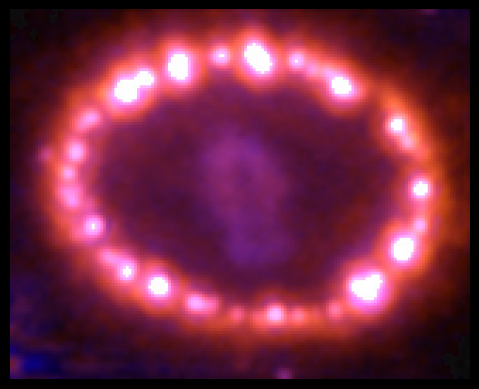

----------------------------------------------------------------------------------------------------
Query Index: 1
----------------------------------------------------------------------------------------------------
Query: Does the context provide numerical uncertainty, error margins, or confidence levels for any distance measurements derived using Cepheids or supernovas?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that astronomers use cyclical changes in the brightness of Cepheid stars to determine astronomical distances. The image shows a Cepheid star in the Andromeda galaxy observed by Hubble.
   - The text states that certain supernovas have a characteristic maximum brightness that can be used to calculate their distances from Earth. The image shows a distant supernova discovered in the Hubble Deep Field.
   - The text states that before Hubble was launched, th

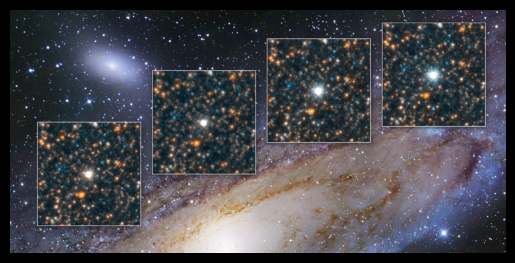

----------------------------------------------------------------------------------------------------
Query Index: 2
----------------------------------------------------------------------------------------------------
Query: Does the context provide enough procedural detail to independently reproduce the Hubble Deep Field supernova identification process?
Answer: 1) Image Assessment
- Images provided: Yes
- Image relevance: Relevant
- Image correctness: Supports text

2) Evidence Analysis
- The text states that astronomers used cyclical changes in Cepheid stars to determine distances and that a supernova was identified by targeting the same area of sky in 1995 and 2002 when a change was observed.
- Image 1 shows a sample of the faintest and farthest galaxies in the Hubble Ultra Deep Field, which were irregularly shaped and frequently interacting. This illustrates the early stages of galaxy formation.
- The text does not provide specific details about the procedure for identifying the su

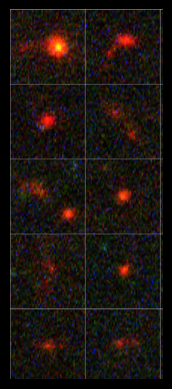

----------------------------------------------------------------------------------------------------
Query Index: 3
----------------------------------------------------------------------------------------------------
Query: Do the provided images alone visually demonstrate cyclical brightness changes required to identify a Cepheid variable, without relying on text labels?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that astronomers use cyclical changes in the brightness of Cepheid stars to determine astronomical distances.
   - Image 1 shows a Cepheid star in the Andromeda galaxy observed by Hubble. The image does not visually demonstrate cyclical brightness changes. 
   - There are no gaps or assumptions in the image itself.

3) Answer
   - The given context is wrong. The images do not visually demonstrate cyclical brightness changes required to identify a Cepheid 

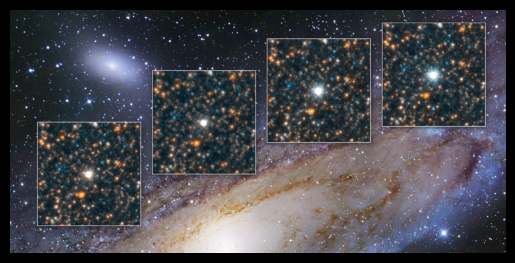

----------------------------------------------------------------------------------------------------
Query Index: 4
----------------------------------------------------------------------------------------------------
Query: Is the identification of the Deep Field supernova visually supported by the image itself, or only by temporal comparison described in the text?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that astronomers found the supernova in the Hubble Deep Field by targeting the same area of sky again in 2002 and seeing a change.
   - Image 1 shows Supernova 1987A as seen by Hubble in 1994. This image does not show the Hubble Deep Field supernova.
   - The image shows the supernova 1987A, but does not show the Deep Field supernova.

3) Answer
   - The identification of the Deep Field supernova is supported by the text’s description of temporal comparison, not

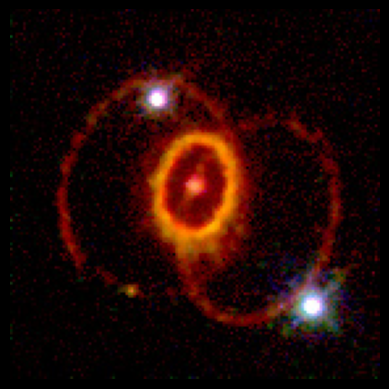

----------------------------------------------------------------------------------------------------
Query Index: 5
----------------------------------------------------------------------------------------------------
Query: Does the Pillars of Creation description rely solely on visible structures in the image, or does it include interpretive claims beyond what is directly observable?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text explicitly states that the “Pillars of Creation” show star birth and that dense, gaseous globules within the tips of the finger-like protrusions are where stars are being born.
   - The image shows the “Pillars of Creation” with finger-like protrusions at the top, and within these protrusions are visible gaseous globules.
   - There are no interpretive claims beyond what is directly observable. The image provides a visual representation of the descr

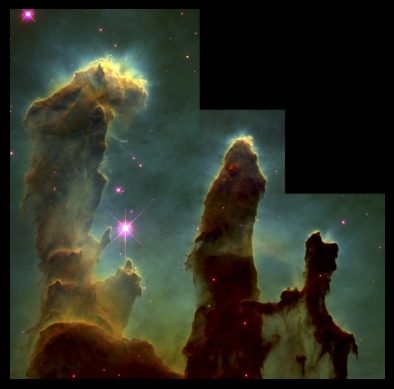

----------------------------------------------------------------------------------------------------
Query Index: 6
----------------------------------------------------------------------------------------------------
Query: Does the Europa plume claim distinguish between spectroscopically detected elements and the inferred presence of subsurface water activity?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that Hubble recorded evidence of transient changes in the atmosphere above the surface of Jupiter’s moon Europa, suspected to be caused by gas plumes expelled from a subsurface ocean.
   - Image 1 shows a depiction of icy objects in the Kuiper Belt. This image is not directly relevant to the question about Europa.
   - The text does not explicitly state whether spectroscopically detected elements distinguish between the inferred presence of subsurface water activity

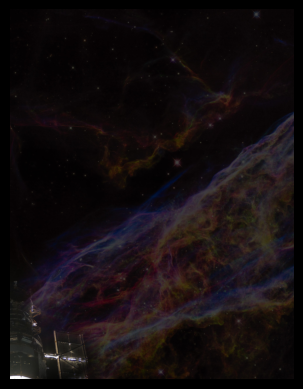

----------------------------------------------------------------------------------------------------
Query Index: 7
----------------------------------------------------------------------------------------------------
Query: Does the context mention any observations that would contradict or weaken the claim of ongoing star formation in the Pillars of Creation?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text explicitly states that the “Pillars of Creation” show star birth, with dense gaseous globules within the tips of the protrusions where stars are being born.
   - Image 1 describes Galileo’s observations and the launch of the Hubble Space Telescope. It does not directly relate to the Pillars of Creation or star formation.
   - The text describes a violent process of star birth, including intense ultraviolet radiation, shock fronts, and the erosion of gas pillars. 

3) Answer


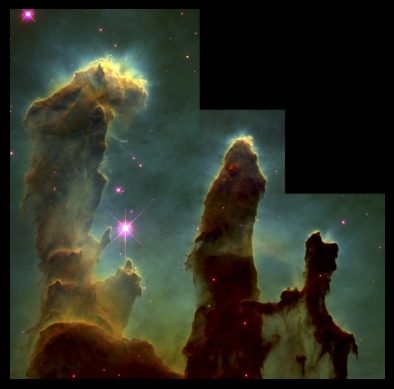

----------------------------------------------------------------------------------------------------
Query Index: 8
----------------------------------------------------------------------------------------------------
Query: Does the gravitational lensing discussion include any stated limitations or alternative explanations for the observed distortions?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text describes gravitational lensing as a technique used to map the distribution of dark matter. It explains how the distorted images of background galaxies and quasars, caused by the gravitational field of massive galaxy clusters, are used to identify the location and properties of the lensing material.
   - Image 1 shows a visualization of gravitational lensing, depicting distorted images of a galaxy and a quasar around a galaxy cluster. The image also illustrates the blue arcs repres

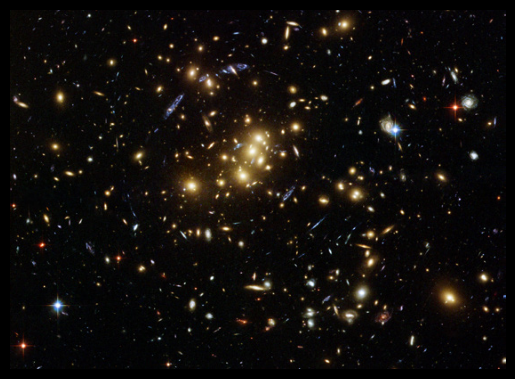

----------------------------------------------------------------------------------------------------
Query Index: 9
----------------------------------------------------------------------------------------------------
Query: Does the gravitational lensing explanation explicitly separate directly observed image distortions from dark matter distributions reconstructed using models?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Cannot be determined

2) Evidence Analysis
   - The text states that astronomers observe warped background galaxies around massive clusters and reverse-engineer their distortions to reveal the location of dark matter.
   - Image 1 shows a visible-light image of a galaxy cluster with blue arcs and a dark matter overlay. The image shows distorted light from background galaxies, but it does not explicitly separate the directly observed image distortions from dark matter distributions reconstructed using mod

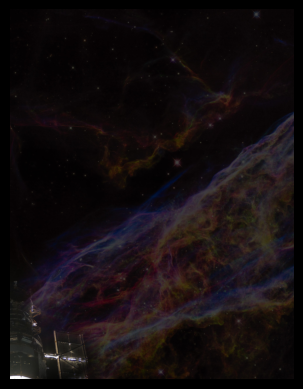

----------------------------------------------------------------------------------------------------
Query Index: 10
----------------------------------------------------------------------------------------------------
Query: Does the black hole interpretation in galaxy M84 explicitly rule out alternative explanations such as dense star clusters using observational constraints?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that the left image shows the bright core of M84 surrounded by a dark band of gas and dust.
   - The right image shows the spectrograph’s sampling slit centered on the core of the galaxy. Spectra taken left and right of the slit show a color shift, indicating blueshifted light from objects moving toward Earth and redshifted light from objects moving away. The text specifies that stars and glowing gases nearest the core of M84 are moving at 880,000 mi

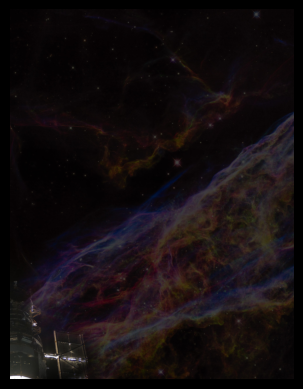

----------------------------------------------------------------------------------------------------
Query Index: 11
----------------------------------------------------------------------------------------------------
Query: Does the Jupiter impact description establish causality purely from observed image sequences, or does it rely on prior knowledge of impact events?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text describes the 2009 impact of a suspected asteroid on Jupiter, leaving a temporary dark feature the size of the Pacific Ocean. It also references the 1994 bombardment of Jupiter by fragments of Comet Shoemaker-Levy 9, where each impact left a black, sooty scar.
   - The image shows a plume rising above the limb of Jupiter, resulting from the impact of Comet Shoemaker-Levy 9. This visually confirms the event described in the text.
   - The text does not explicitly st

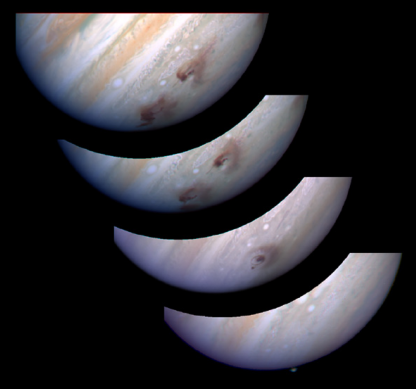

----------------------------------------------------------------------------------------------------
Query Index: 12
----------------------------------------------------------------------------------------------------
Query: Does the Europa plume interpretation present a direct causal chain from observation to conclusion, or does it acknowledge interpretive assumptions?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that Hubble found spectroscopic evidence of oxygen and hydrogen on Europa, suggesting water vapor plumes erupting from beneath the surface.
   - Image 1 shows “Viewing Galactic Details and Mergers,” which is not directly relevant to the text’s discussion of Europa’s plumes and the Voyager missions.
   - The text explicitly states the interpretation of the disturbances in Europa’s atmosphere as caused by gas plumes expelled from a subsurface ocean. It acknow

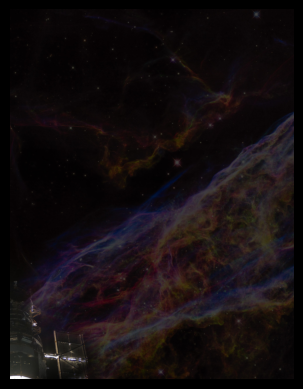

----------------------------------------------------------------------------------------------------
Query Index: 13
----------------------------------------------------------------------------------------------------
Query: Does the Pluto composite image explanation include sufficient detector or exposure metadata to independently validate the imaging strategy?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text states that the Hubble image combines a long exposure (blue areas) to capture tiny moons and a shorter exposure (vertical black band) to show Pluto and Charon more clearly.
   - The image shows this combination of exposures: a blue area representing the long exposure and a vertical black band representing the shorter exposure.
   - The text states that objects are not to scale. However, the image does not provide any metadata regarding detector or exposure settings (e.g.,

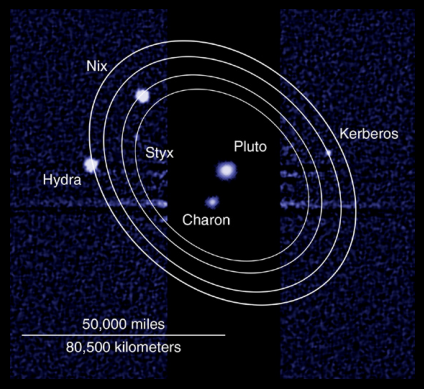

----------------------------------------------------------------------------------------------------
Query Index: 14
----------------------------------------------------------------------------------------------------
Query: Does the Voyager mission description provide enough quantitative trajectory or timing data to independently reconstruct the spacecraft flyby sequence?
Answer: 1) Image Assessment
   - Images provided: Yes
   - Image relevance: Relevant
   - Image correctness: Supports text

2) Evidence Analysis
   - The text describes Voyager 1’s launch on September 5, 1977, at a distance of 7.25 million miles, capturing the first photograph of the Earth-Moon system on September 18, 1977.
   - The image shows the first photograph of the Earth-Moon system taken by Voyager 1 and a depiction of the Voyager spacecraft in space.
   - The text mentions Voyager 1’s trajectory change due to the Titan flyby, preventing further planetary encounters. The image does not provide quantitative tr

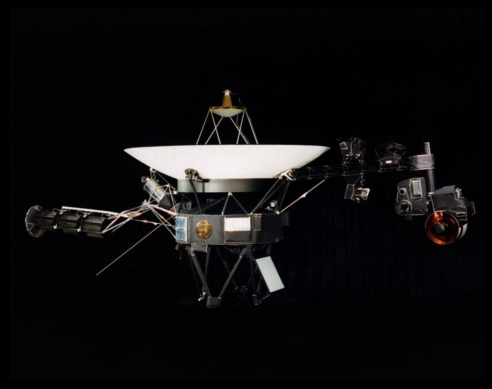

In [58]:
llm_response()

In [59]:
formatted_output

[{'query': 'Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?',
  'text_context': '[1] Above: Astronomers use cyclical changes in the \nbrightness of Cepheid stars to determine astronomical \ndistances. The arrow points to a Cepheid star in the \nAndromeda galaxy observed by Hubble (inset boxes).\nRight: Certain supernovas have a characteristic \nmaximum brightness that can be used to calculate their \ndistances from Earth. Refining celestial distances enables \nastronomers to better calculate the expansion rate of \nthe universe. The arrow points to a distant supernova \ndiscovered in an area of the sky first imaged in 1995 \ncalled the Hubble Deep Field. Astronomers found the \nsupernova when they targeted the same area of sky again \nin 2002 and saw a change.\n(Source: highlights_of_hubbles_exploration_of_the_universe.pdf, page 3)\n\n[2] Shown here are two Hubble views

In [60]:
llm.set_model()

╒══════════╤══════════════════╤══════════════╕
│   Serial │ Model Name       │ Parameters   │
╞══════════╪══════════════════╪══════════════╡
│        0 │ ministral-3:3b   │ 3.8B         │
├──────────┼──────────────────┼──────────────┤
│        1 │ llava-phi3:3.8b  │ 4B           │
├──────────┼──────────────────┼──────────────┤
│        2 │ qwen3-vl:4b      │ 4.4B         │
├──────────┼──────────────────┼──────────────┤
│        3 │ codellama:7b     │ 7B           │
├──────────┼──────────────────┼──────────────┤
│        4 │ gemma3:4b        │ 4.3B         │
├──────────┼──────────────────┼──────────────┤
│        5 │ deepseek-r1:1.5b │ 1.8B         │
╘══════════╧══════════════════╧══════════════╛
Model 'ministral-3:3b' selected.


----------------------------------------------------------------------------------------------------
Query Index: 0
----------------------------------------------------------------------------------------------------
Query: Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?
Answer: 1) **Image Assessment**
   - **Images provided:** No
   - **Image relevance:** Not relevant
   - **Image correctness:** Not applicable

2) **Evidence Analysis**
   - The provided text context explicitly states that astronomers use **cyclical changes in the brightness of Cepheid stars** to determine astronomical distances, but it does **not** explicitly describe **how** these changes are measured. Instead, it mentions that these changes are a tool used for this purpose.
   - The text describes the observational method in broad terms: astronomers observe these stars over time to detect their perio

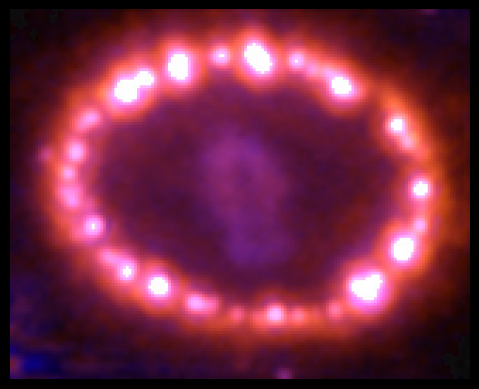

----------------------------------------------------------------------------------------------------
Query Index: 1
----------------------------------------------------------------------------------------------------
Query: Does the context provide numerical uncertainty, error margins, or confidence levels for any distance measurements derived using Cepheids or supernovas?
Answer: 1) **Image Assessment**
   - **Images provided:** Yes
   - **Image relevance:** The provided image shows the Andromeda galaxy with inset boxes highlighting individual star clusters, not Cepheid stars or supernovae. It visually represents a broad field rather than specific observations tied to the text.
   - **Image correctness:** The image supports the broader theme of galaxy observation but does not illustrate or confirm the use of Cepheid stars or supernovae as explicitly described in the text.

---

2) **Evidence Analysis**
   **From the provided text:**
   - The text discusses methods used by astronomers,

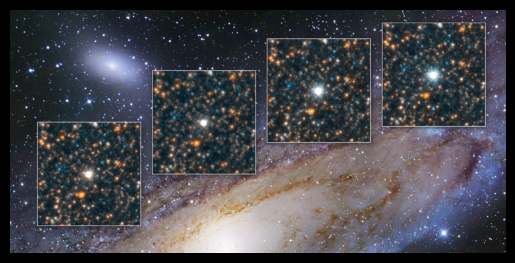

----------------------------------------------------------------------------------------------------
Query Index: 2
----------------------------------------------------------------------------------------------------
Query: Does the context provide enough procedural detail to independently reproduce the Hubble Deep Field supernova identification process?
Answer: 1) **Image Assessment**
   - **Images provided:** No
   - **Image relevance:** None (since no images were provided)
   - **Image correctness:** Not applicable

---

2) **Evidence Analysis**

   The provided text explicitly describes key steps for Hubble’s supernova identification process but does **not** provide procedural details sufficient to independently reproduce it. Here is a summary of the relevant text:

   - **Context [3]:** Astronomers use:
     1. Cepheid variable stars (via their cyclical brightness changes) to determine distances.
     2. Supernovae with a characteristic maximum brightness to calculate distances by

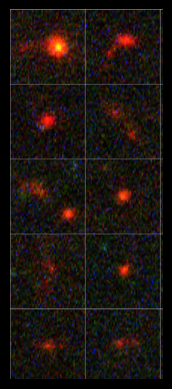

----------------------------------------------------------------------------------------------------
Query Index: 3
----------------------------------------------------------------------------------------------------
Query: Do the provided images alone visually demonstrate cyclical brightness changes required to identify a Cepheid variable, without relying on text labels?
Answer: 1) **Image Assessment**
   - **Images provided:** Yes
   - **Image relevance:** Partially relevant
   - **Image correctness:** Cannot be determined (neither directly supports nor contradicts text claims)

---

2) **Evidence Analysis**
   - The provided **text context explicitly states** that Cepheid stars exhibit cyclical brightness changes, which astronomers use to determine distances. These stars are highlighted in inset boxes.
   - The **image alone does not show cyclical brightness variations directly**. Instead, it shows:
     - A wide-field background of galaxies (including Andromeda) and bright star clu

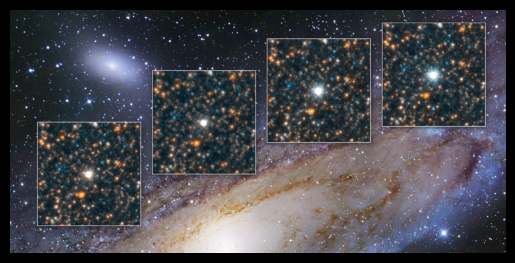

----------------------------------------------------------------------------------------------------
Query Index: 4
----------------------------------------------------------------------------------------------------
Query: Is the identification of the Deep Field supernova visually supported by the image itself, or only by temporal comparison described in the text?
Answer: 1) **Image Assessment**
   - Images provided: Yes (one provided image is the Hubble depiction of a ring-like structure in the context of SN 1987A, but not linked directly to the Hubble Deep Field supernova).
   - Image relevance: The provided image is **not** the Hubble Deep Field supernova; it is a visual of **SN 1987A in 1994** as described in the text.
   - Image correctness: The provided image **supports the description of SN 1987A** (ring-like glowing ring of shocked material), but it does **not** depict the Hubble Deep Field supernova. This image is not relevant to the Hubble Deep Field question.

---

2) **Evi

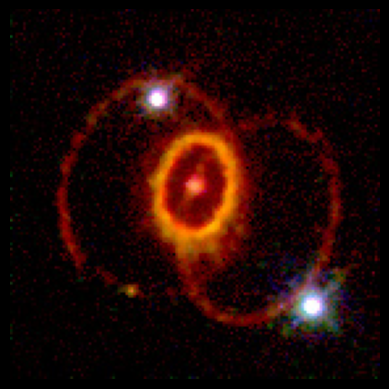

----------------------------------------------------------------------------------------------------
Query Index: 5
----------------------------------------------------------------------------------------------------
Query: Does the Pillars of Creation description rely solely on visible structures in the image, or does it include interpretive claims beyond what is directly observable?
Answer: 1) **Image Assessment**
   - **Images provided:** Yes
   - **Image relevance:** Partially relevant
     The image shows the Pillars of Creation in the Eagle Nebula (M16), which aligns with the provided text context. However, the image does not provide direct visual confirmation of specific claims such as "dense gaseous globules" at the tips of protrusions or the nature of dark matter structures.
   - **Image correctness:**
     The image *supports* the visible structural features of the Pillars of Creation (e.g., the finger-like protrusions and columnar formations) but **cannot confirm or refute t

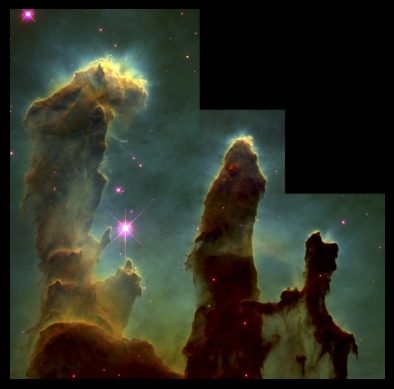

----------------------------------------------------------------------------------------------------
Query Index: 6
----------------------------------------------------------------------------------------------------
Query: Does the Europa plume claim distinguish between spectroscopically detected elements and the inferred presence of subsurface water activity?
Answer: 1) **Image Assessment**
   - Images provided: No
   - Image relevance: Not relevant to the question
   - Image correctness: N/A

---

2) **Evidence Analysis**
   The provided text explicitly states:

   - Hubble detected **spectroscopic evidence of oxygen and hydrogen** on Europa’s surface, which are elements in water molecules, **suggesting water vapor plumes erupting from beneath the surface**. This is inferred from the presence of these elements and visual evidence of plumes (referenced in the context but not directly linked to spectral data distinction).

   - The text also mentions **subsurface ocean activity** on E

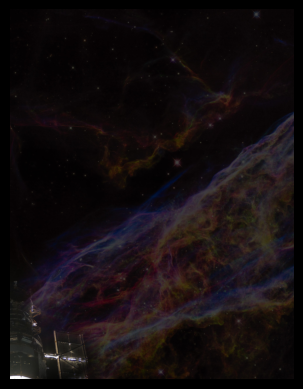

----------------------------------------------------------------------------------------------------
Query Index: 7
----------------------------------------------------------------------------------------------------
Query: Does the context mention any observations that would contradict or weaken the claim of ongoing star formation in the Pillars of Creation?
Answer: 1) **Image Assessment**
   - **Images provided:** Yes
   - **Image relevance:** Relevant (the image depicts the Pillars of Creation, the same nebula referenced in the text)
   - **Image correctness:** Cannot be determined (no explicit claims of star formation or contradictory observations in the image caption; it shows nebular structures but does not provide descriptive text or analysis).

---

2) **Evidence Analysis**
   - **What the text explicitly states:**
     - The Pillars of Creation (in the Eagle Nebula, M16) is described as a site of star birth.
     - Gaseous globules at the tips of the columns are dense regions 

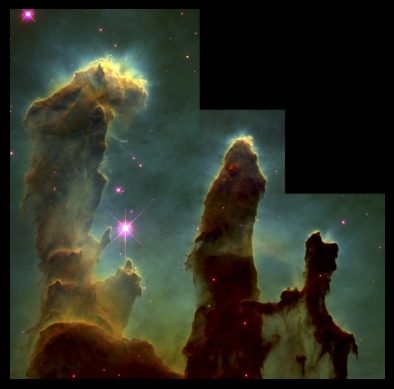

----------------------------------------------------------------------------------------------------
Query Index: 8
----------------------------------------------------------------------------------------------------
Query: Does the gravitational lensing discussion include any stated limitations or alternative explanations for the observed distortions?
Answer: 1) **Image Assessment**
   - **Images provided**: Yes (referenced in the captions for gravitational lensing sketches and the galaxy cluster images).
   - **Image relevance**: The image provided in the question does not directly match the references (e.g., SDSS J1004+4112 or Cl 0024+17). However, it *is relevant* in that it depicts a dense cluster of galaxies with numerous background sources, suggesting gravitational lensing.
     - **Image correctness**: The image supports the general concept of gravitational lensing (e.g., warped light paths and distorted galaxy images) as described in the text, though it does not explicitly sho

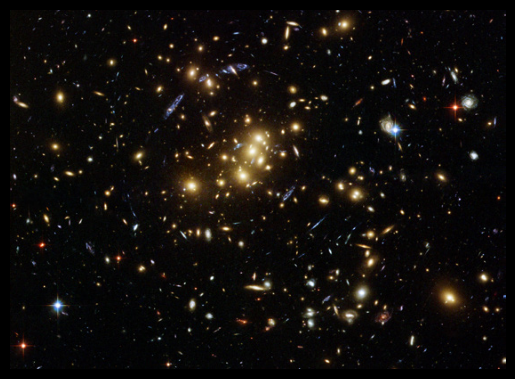

----------------------------------------------------------------------------------------------------
Query Index: 9
----------------------------------------------------------------------------------------------------
Query: Does the gravitational lensing explanation explicitly separate directly observed image distortions from dark matter distributions reconstructed using models?
Answer: 1) **Image Assessment**
   - **Images provided:** Yes (not explicitly provided here in this chat but described in the text)
     - The descriptions mention two sets of images: one showing visible-light distortions of galaxies behind a galaxy cluster (left) and another overlay (right) showing dark matter density.
     - The image you provided is unrelated to this context and appears to show a cosmic structure (likely a nebula or star-forming region) rather than gravitational lensing.

   - **Image relevance:** *Not relevant* to the specific question regarding SDSS J1004+4112 and its lensed images.
   - *

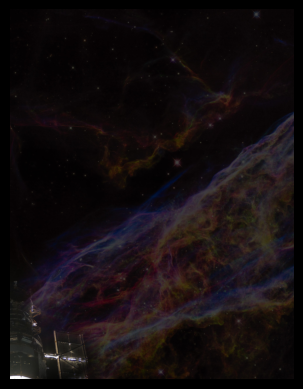

----------------------------------------------------------------------------------------------------
Query Index: 10
----------------------------------------------------------------------------------------------------
Query: Does the black hole interpretation in galaxy M84 explicitly rule out alternative explanations such as dense star clusters using observational constraints?
Answer: 1) **Image Assessment**
   - **Images provided:** No
   - **Image relevance:** Not applicable (no images provided for this question).
   - **Image correctness:** N/A

---

2) **Evidence Analysis**
   **From the provided text context:**
   - The Hubble observations of M84 focus on the central core, a vertical dark band of gas and dust, and a spectrographic analysis showing blueshifted and redshifted light near the core.
   - The blueshift and redshift indicate rapid motion of stars and gas in an orbiting pattern, suggesting a central supermassive object causing such velocity dispersion.
   - This is consis

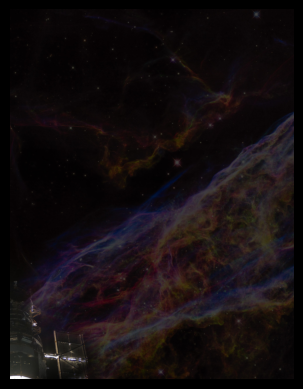

----------------------------------------------------------------------------------------------------
Query Index: 11
----------------------------------------------------------------------------------------------------
Query: Does the Jupiter impact description establish causality purely from observed image sequences, or does it rely on prior knowledge of impact events?
Answer: 1) **Image Assessment**
   - Images provided: Yes
   - Image relevance: Partially relevant
     (The images visually depict the progression of darkening and plume formation on Jupiter, consistent with the effects of a comet impact, but the sequence does not explicitly label the objects or provide timestamps or physical context.)
   - Image correctness:
     Supports text but does not establish causality purely from the images alone without additional supporting evidence or metadata.

---

2) **Evidence Analysis**
   - **Text Explicitly States:**
     - Hubble witnessed impacts on Jupiter, including Comet Shoemake

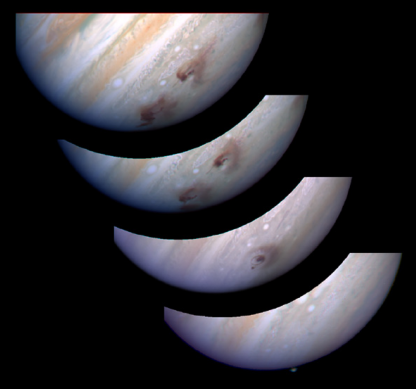

----------------------------------------------------------------------------------------------------
Query Index: 12
----------------------------------------------------------------------------------------------------
Query: Does the Europa plume interpretation present a direct causal chain from observation to conclusion, or does it acknowledge interpretive assumptions?
Answer: 1) **Image Assessment**
   - Images provided: **No** (No specific images of Europa plume were included in the question or provided here; the provided image is unrelated to Jupiter/Europa.)
   - Image relevance: **Not relevant** (The image shows a deep-space nebula, unrelated to Europa plumes or Hubble’s findings.)

---

2) **Evidence Analysis**
   **Text Context Summary:**
   The provided text explicitly mentions Hubble’s spectroscopic evidence for water vapor plumes on Europa and its visual confirmation of such plumes. The text does **not** provide a detailed causal chain but rather states that:
   - Hubble det

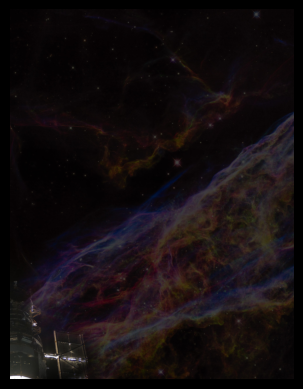

----------------------------------------------------------------------------------------------------
Query Index: 13
----------------------------------------------------------------------------------------------------
Query: Does the Pluto composite image explanation include sufficient detector or exposure metadata to independently validate the imaging strategy?
Answer: 1) **Image Assessment**
   - **Images provided:** Yes
   - **Image relevance:** Relevant
   - **Image correctness:** Supports the text
     *(The provided image aligns with the Hubble graphic described in the text context, showing Pluto’s moons in varying exposures and an absence of scale references.)*

---

2) **Evidence Analysis**
   - **What the text explicitly states:**
     - The graphic combines **Hubble images taken in July 2012**.
     - A **long exposure** (blue areas) captures tiny moons (Nix, Hydra, Styx, Kerberos).
     - A **shorter exposure** (vertical black band) highlights Pluto and Charon more distinctl

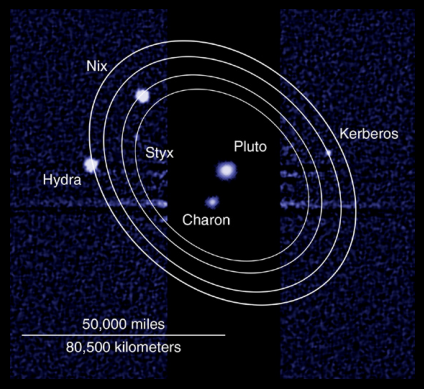

----------------------------------------------------------------------------------------------------
Query Index: 14
----------------------------------------------------------------------------------------------------
Query: Does the Voyager mission description provide enough quantitative trajectory or timing data to independently reconstruct the spacecraft flyby sequence?
Answer: ---

### **1) Image Assessment**
- **Images provided:** Yes
  - The provided image depicts the **Voyager 1 spacecraft** in its operational configuration.
- **Image relevance:** Partially relevant
  - The image shows the spacecraft’s physical design but does not explicitly display trajectory diagrams, timelines, or quantitative data (e.g., distances, dates, or angular deviations).
- **Image correctness:**
  - **Supports text** insofar as it visually confirms the Voyager 1 spacecraft’s design aligns with historical records described in the provided text.

---

### **2) Evidence Analysis**

#### **Text Summary:*

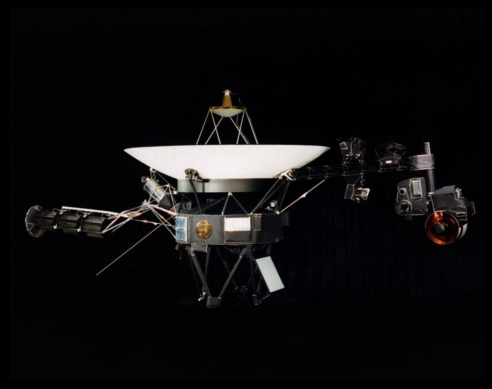

In [61]:
llm_response()